# Mathematica-Style Equilibrium Panel — Credit Rationing Channel (PQC)

Produces a 2×2 composite panel for the `PKAssetPrices.Static.PQC` scenario, matching the
visual style of `graphtest-money.nb` (purple/orange colour scheme, percentage
tick labels, Mathematica-style layout). The Baseline solution is overlaid as grey
reference lines on the curves that shift.

**Requires:** `PKAssetPrices`, `CairoMakie`

In [10]:
using PKAssetPrices
using PKAssetPrices.Static: solve_model, eval_curve
using CairoMakie
using Printf
# ── Colour palette (Mathematica graphtest-money.nb) ──
const CURVE_COLOR  = RGBf(0.5, 0.0, 0.5)    # purple  – IS, AD, asset demand
const SUPPLY_COLOR = RGBf(1.0, 0.5, 0.0)    # orange  – IR, AS, asset supply
const BASELINE_COLOR = RGBf(0.45, 0.45, 0.45)  # grey    – baseline reference
const COUNTERFACT  = (CURVE_COLOR, 0.38)     # faded purple – counterfactual
# Balance-sheet palette
const BS_ASSET     = CURVE_COLOR  # purple – assets
const BS_LIABILITY = SUPPLY_COLOR # orange – liabilities
const PLOT_RANGES = (
    IS_IR_X = (4.0, 10.0),
    IS_IR_Y = (0.06, 0.15),
    AD_AS_X = (5.5, 8.5),
    AD_AS_Y = (1.2, 2.2),
    AM_X    = (0.6, 1.3),
    AM_Y    = (0.7, 1.3),
)
FONT_SIZE   = 20
TITLE_SIZE  = 26
LEGEND_SIZE = 20


20

In [11]:
# ── 1. Solve model ─────────────────────────────────────────────────────
solution = solve_model(PKAssetPrices.Static.FirmsRation)
vars     = solution.variables
Y_eq   = vars[:Y]
r_eq   = vars[:r]
P_eq   = vars[:P]
AP_eq  = vars[:AP]
dL_val = vars[:dL]
dM_val = vars[:dM]
dR_val = vars[:dR]
println("Baseline model solved.")
println("  Y  = $(round(Y_eq, sigdigits=5))")
println("  r  = $(round(r_eq, sigdigits=5))")
println("  P  = $(round(P_eq, sigdigits=5))")
println("  AP = $(round(AP_eq, sigdigits=5))")


Baseline model solved.
  Y  = 4.9889
  r  = 0.10313
  P  = 1.5936
  AP = 1.0569


In [12]:
# ── Baseline reference solution (grey comparison lines) ──
baseline_solution = solve_model(PKAssetPrices.Static.Baseline)
baseline_vars = baseline_solution.variables
baseline_model = baseline_solution.model
# Baseline with interest-rate shock (lower i₀) — grey reference mirroring Fig 2 counterfactual
lower_baseline_model = PKAssetPrices.Static.Parametrization(
    baseline_model.model,
    merge(copy(baseline_model.params), Dict(:i0 => 0.0)),
    copy(baseline_model.u0),
)
lower_baseline_sol = PKAssetPrices.Static.solve_model(lower_baseline_model)
println("Baseline reference solved (grey comparison lines).")


Baseline reference solved (grey comparison lines).


In [13]:
# ── 2. Build figure ─────────────────────────────────────────────────────
fig = Figure(
    size = (1400, 1000),
    fontsize = FONT_SIZE,
    figure_padding = (28, 38, 28, 28),
    backgroundcolor = :white,
)
# ── Panel A: Goods Market Dynamics (IS/IR) ───────────────────────────
ax1 = Axis(
    fig[1, 1];
    title = "(A) Goods Market Dynamics",
    xlabel = "Output Y",
    ylabel = "interest rate r",
    xgridcolor = (:black, 0.12),
    ygridcolor = (:black, 0.12),
    titlesize = TITLE_SIZE,
    xlabelsize = FONT_SIZE,
    ylabelsize = FONT_SIZE,
    bottomspinecolor = :black,
    topspinecolor = :black,
    leftspinecolor = :black,
    rightspinecolor = :black,
)
# IS curve: r → Y
r_range = range(PLOT_RANGES.IS_IR_Y...; length = 200)
is_Y = map(r_range) do r
    v = copy(vars); v[:r] = r
    eval_curve(solution.model, v).IS
end
lines!(ax1, is_Y, r_range; color = SUPPLY_COLOR, linewidth = 3, label = "IS")
# IR curve: Y → r
y_range1 = range(PLOT_RANGES.IS_IR_X...; length = 200)
ir_r = map(y_range1) do y
    v = copy(vars); v[:Y] = y
    eval_curve(solution.model, v).IR
end
lines!(ax1, y_range1, ir_r; color = CURVE_COLOR, linewidth = 3, label = "IR")
# Counterfactual IR (lower i₀)
lower_model = PKAssetPrices.Static.Parametrization(
    solution.model.model,
    merge(copy(solution.model.params), Dict(:i0 => 0.0)),
    copy(solution.model.u0),
)
lower_ir_r = map(y_range1) do y
    v = copy(vars); v[:Y] = y
    eval_curve(lower_model, v).IR
end
lines!(ax1, y_range1, lower_ir_r;
    color = CURVE_COLOR, linewidth = 3, linestyle = :dash,
    label = "IR (lower i₀)")
# ── Baseline reference (grey comparison) ──
base_is_Y = map(r_range) do r
    v = copy(baseline_vars); v[:r] = r
    eval_curve(baseline_model, v).IS
end
lines!(ax1, base_is_Y, r_range; color = BASELINE_COLOR, linewidth = 3, label = "IS")
text!(ax1, 7.6, 0.075; text = "IS (base)", space = :data,
    color = BASELINE_COLOR, fontsize = LEGEND_SIZE , align = (:center, :center))
xlims!(ax1, PLOT_RANGES.IS_IR_X...)
ylims!(ax1, PLOT_RANGES.IS_IR_Y...)
# Inline labels (no legend box) — relative coordinates guarantee inside chart
text!(ax1, 6.6, 0.14; text = "IS", space = :data,
    color = SUPPLY_COLOR, fontsize = LEGEND_SIZE, align = (:right, :top))
text!(ax1, 9.5, 0.139; text = "IR", space = :data,
    color = CURVE_COLOR, fontsize = LEGEND_SIZE, align = (:center, :top))
text!(ax1, 9.3, 0.11; text = "IR (lower i₀)", space = :data,
    color = CURVE_COLOR, fontsize = LEGEND_SIZE, align = (:center, :top))
ax1


Axis with 8 plots:
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}
 ┗━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}


In [14]:
# display(fig)


In [15]:
# ── Panel B: Output and Inflation Dynamics (AD/AS) ──────────────────
ax2 = Axis(
    fig[1, 2];
    title = "(B) Output and Inflation Dynamics",
    xlabel = "Output Y",
    ylabel = "Price Level P",
    xgridcolor = (:black, 0.12),
    ygridcolor = (:black, 0.12),
    titlesize = TITLE_SIZE,
    xlabelsize = FONT_SIZE,
    ylabelsize = FONT_SIZE,
    bottomspinecolor = :black,
    topspinecolor = :black,
    leftspinecolor = :black,
    rightspinecolor = :black,
)
# AD curve: P → Y
p_range = range(PLOT_RANGES.AD_AS_Y...; length = 200)
ad_Y = map(p_range) do p
    v = copy(vars); v[:P] = p
    eval_curve(solution.model, v).ADc
end
lines!(ax2, ad_Y, p_range; color = CURVE_COLOR, linewidth = 3, label = "AD")
# AS curve: Y → P
y_range2 = range(PLOT_RANGES.AD_AS_X...; length = 200)
as_P = map(y_range2) do y
    v = copy(vars); v[:Y] = y
    eval_curve(solution.model, v).ASc
end
lines!(ax2, y_range2, as_P; color = SUPPLY_COLOR, linewidth = 3, label = "AS")
# AD counterfactual (lower i₀)
lower_ad_Y = map(p_range) do p
    v = copy(vars); v[:P] = p
    eval_curve(lower_model, v).ADc
end
lines!(ax2, lower_ad_Y, p_range;
    color = CURVE_COLOR, linewidth = 3, linestyle = :dash,
    label = "AD (lower i₀)")
# ── Baseline reference (grey comparison) ──
base_ad_Y = map(p_range) do p
    v = copy(baseline_vars); v[:P] = p
    eval_curve(baseline_model, v).ADc
end
lines!(ax2, base_ad_Y, p_range; color = BASELINE_COLOR, linewidth = 2.5, label = "AD (base)")
text!(ax2, 7.4, 1.3; text = "AD (base)", space = :data,
    color = BASELINE_COLOR, fontsize = LEGEND_SIZE, align = (:center, :center))
lower_baseline_ad_Y = map(p_range) do p
    v = copy(lower_baseline_sol.variables); v[:P] = p
    eval_curve(lower_baseline_model, v).ADc
end
lines!(ax2, lower_baseline_ad_Y, p_range; color = BASELINE_COLOR, linewidth = 3, linestyle = :dash,
    label = "AD (lower i₀)")

xlims!(ax2, PLOT_RANGES.AD_AS_X...)
ylims!(ax2, PLOT_RANGES.AD_AS_Y...)
# Inline labels (no legend box) — relative coordinates
text!(ax2, 0.1, 0.88; text = "AD", space = :relative,
    color = CURVE_COLOR, fontsize = LEGEND_SIZE, align = (:left, :top))
# text!(ax2, 0.35, 0.45; text = "AD (lower i₀)", space = :relative,
#     color = CURVE_COLOR, fontsize = LEGEND_SIZE, align = (:left, :top))
textlabel!(ax2, Point2f(0.35, 0.45); text = "AD (lower i₀)", space = :relative,
    text_color = CURVE_COLOR, fontsize = LEGEND_SIZE, text_align = (:left, :top),
    background_color = (:white, 0.8), strokecolor = (:white, 0.8), padding = 8)
text!(ax2, 0.92, 0.8; text = "AS", space = :relative,
    color = SUPPLY_COLOR, fontsize = LEGEND_SIZE, align = (:right, :top))
ax2


Axis with 9 plots:
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}
 ┣━ TextLabel{Tuple{Vector{Point{2, Float32}}}}
 ┗━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}


In [16]:
# ── Panel C: Financial Market Dynamics (Asset Market) ──────────────
ax3 = Axis(
    fig[2, 1];
    title = "(C) Financial Market Dynamics",
    xlabel = "Quantity of assets traded",
    ylabel = "Asset Price AP",
    xgridcolor = (:black, 0.12),
    ygridcolor = (:black, 0.12),
    titlesize = TITLE_SIZE,
    xlabelsize = FONT_SIZE,
    ylabelsize = FONT_SIZE,
    bottomspinecolor = :black,
    topspinecolor = :black,
    leftspinecolor = :black,
    rightspinecolor = :black,
)
ap_range = range(PLOT_RANGES.AM_X...; length = 200)
# Asset demand (AMD)
amd_Q = map(ap_range) do ap
    v = copy(vars); v[:AP] = ap
    eval_curve(solution.model, v).AMD
end
lines!(ax3, amd_Q, ap_range; color = CURVE_COLOR, linewidth = 4,
    label = "Asset Demand")
# Asset supply (AMS)
ams_Q = map(ap_range) do ap
    v = copy(vars); v[:AP] = ap
    eval_curve(solution.model, v).AMS
end
lines!(ax3, ams_Q, ap_range; color = SUPPLY_COLOR, linewidth = 3,
    label = "Asset Supply")
# Counterfactual demand (lower i₀)
lower_sol = solve_model(lower_model)
lower_amd_Q = map(ap_range) do ap
    v = copy(lower_sol.variables); v[:AP] = ap
    eval_curve(lower_model, v).AMD
end
lines!(ax3, lower_amd_Q, ap_range;
    color = CURVE_COLOR, linewidth = 3, linestyle = :dash,
    label = "Demand (lower i₀)")
# ── Baseline reference (grey comparison) ──
base_amd_Q = map(ap_range) do ap
    v = copy(baseline_vars); v[:AP] = ap
    eval_curve(baseline_model, v).AMD
end
lines!(ax3, base_amd_Q, ap_range; color = BASELINE_COLOR, linewidth = 2.5, label = "Asset Demand (base)")
text!(ax3, 0.69, 0.9, ap_range[100]; text = "Asset Demand\n(base)", space = :data,
    color = BASELINE_COLOR, fontsize = LEGEND_SIZE, align = (:center, :bottom))
# AMD (lower i₀, interest-rate shock): dashed grey — baseline AMD shifted by lower i₀, mirrors Fig 2
lower_baseline_amd_Q = map(ap_range) do ap
    v = copy(lower_baseline_sol.variables); v[:AP] = ap
    eval_curve(lower_baseline_model, v).AMD
end
# Plot the grey dashed baseline-AMD-with-lower-i₀ line (mirrors Fig 2)
lines!(ax3, lower_baseline_amd_Q, ap_range; color = BASELINE_COLOR, linewidth = 2.5, linestyle = :dash,
    label = "AMD (base, lower i₀)")

xlims!(ax3, PLOT_RANGES.AM_X...)
ylims!(ax3, PLOT_RANGES.AM_Y...)
# Inline labels (no legend box) — relative coordinates
text!(ax3, 0.5, 0.1; text = "Asset Demand", space = :relative,
    color = CURVE_COLOR, fontsize = LEGEND_SIZE - 1, align = (:left, :top))
text!(ax3, 0.22, 0.03; text = "Asset Supply", space = :relative,
    color = SUPPLY_COLOR, fontsize = LEGEND_SIZE - 1, align = (:right, :bottom))
text!(ax3, 0.86, 0.35; text = "Asset Demand\n(lower i₀)", space = :relative,
    color = CURVE_COLOR, fontsize = LEGEND_SIZE, align = (:center, :top))
ax3


Axis with 10 plots:
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Makie.Text{Tuple{Vector{Point{3, Float64}}}}
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}
 ┗━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}


In [17]:
# ── Panel D: Sector Balance Sheets ───────────────────────────────────
ax4 = Axis(
    fig[2, 2];
    title = rich("(D) ", "Balance Sheet Analysis"; font = :bold),
    ylabel = "Amount",
    xgridvisible = false,
    ygridcolor = (:black, 0.08),
    titlesize = TITLE_SIZE,
    xlabelsize = FONT_SIZE,
    ylabelsize = FONT_SIZE,
    bottomspinecolor = :black,
    topspinecolor = :black,
    leftspinecolor = :black,
    rightspinecolor = :black,
)
# Balance-sheet values
dL_val = vars[:dL]
dM_val = vars[:dM]
dR_val = vars[:dR]
# 8 segments (3 sectors, Banks stacked: Loans+Reserves, Deposits+CB credit)
inner_gap = 1.2      # gap within a sector pair
group_gap = 1.6      # gap between sectors
start_x   = 1.1
positions = [
    start_x,
    start_x + inner_gap,
    start_x + inner_gap + group_gap,
    start_x + inner_gap + group_gap,
    start_x + inner_gap + group_gap + inner_gap,
    start_x + inner_gap + group_gap + inner_gap,
    start_x + 2*inner_gap + 2*group_gap,
    start_x + 2*inner_gap + 2*group_gap + inner_gap,
]
bar_vals = [dM_val, dL_val, dL_val, dR_val, dM_val, dR_val, dR_val, dR_val]
bar_clrs = [BS_ASSET, BS_LIABILITY, BS_ASSET, BS_ASSET, BS_LIABILITY, BS_LIABILITY, BS_ASSET, BS_LIABILITY]
bar_stck = Int[1, 2, 3, 3, 4, 4, 5, 6]
bar_lbls = [
    @sprintf("D: %.1f", dM_val),
    @sprintf("L: %.1f", dL_val),
    @sprintf("L: %.1f", dL_val),
    @sprintf("R: %.1f", dR_val),
    @sprintf("D: %.1f", dM_val),
    @sprintf("CB: %.1f", dR_val),
    @sprintf("CB: %.1f", dR_val),
    @sprintf("R: %.1f", dR_val),
]
barplot!(ax4, positions, bar_vals;
    stack = bar_stck, width = 1.2, color = bar_clrs,
    strokecolor = (:black, 0.65), strokewidth = 1.5,
    bar_labels = bar_lbls,
    label_position = :center, label_color = :black, label_size = 14,
)
hlines!(ax4, [0.0]; color = (:black, 0.55), linewidth = 1.5)
# Sector separator lines
vlines!(ax4, [3.1, 5.9]; ymin = 0.0, ymax = 0.75, color = (:black, 0.35), linewidth = 1.0, linestyle = :dash)
# Indicator text in top-right corner
risk = get(vars, :SD, 0.0) / dL_val
annotation = join([
    @sprintf("Total Debt / GDP: %.2f", dL_val / vars[:Y]),
    @sprintf("Speculative Debt / Total Debt: %.2f", risk),
], '\n')
text!(ax4, 0.97, 0.97; text = annotation, space = :relative,
    align = (:right, :top), fontsize = FONT_SIZE - 2, color = (:black, 0.75))
# Sector labels (smaller, below the indicators)
text!(ax4, [1.7, 4.5, 7.3], fill(5.2, 3);
    text = ["Private Sector", "Banks", "Central Bank"],
    align = (:center, :bottom), font = :bold, fontsize = FONT_SIZE,
    color = :black)
# x-ticks: alternating Assets / Liabilities
    xs = [start_x,
    start_x + inner_gap,
    start_x + inner_gap + group_gap,
    start_x + inner_gap + group_gap + inner_gap,
    start_x + 2*inner_gap + 2*group_gap,
    start_x + 2*inner_gap + 2*group_gap + inner_gap]
    labels = ["Assets", "Liabilities", "Assets", "Liabilities", "Assets", "Liabilities"]
    ax4.xticks = (xs, labels)
xlims!(ax4, 0.3, 8.7)
ylims!(ax4, 0.0, 8.0)
ax4


Axis with 5 plots:
 ┣━ BarPlot{Tuple{Vector{Point{2, Float64}}}}
 ┣━ HLines{Tuple{Vector{Float64}}}
 ┣━ VLines{Tuple{Vector{Float64}}}
 ┣━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}
 ┗━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}


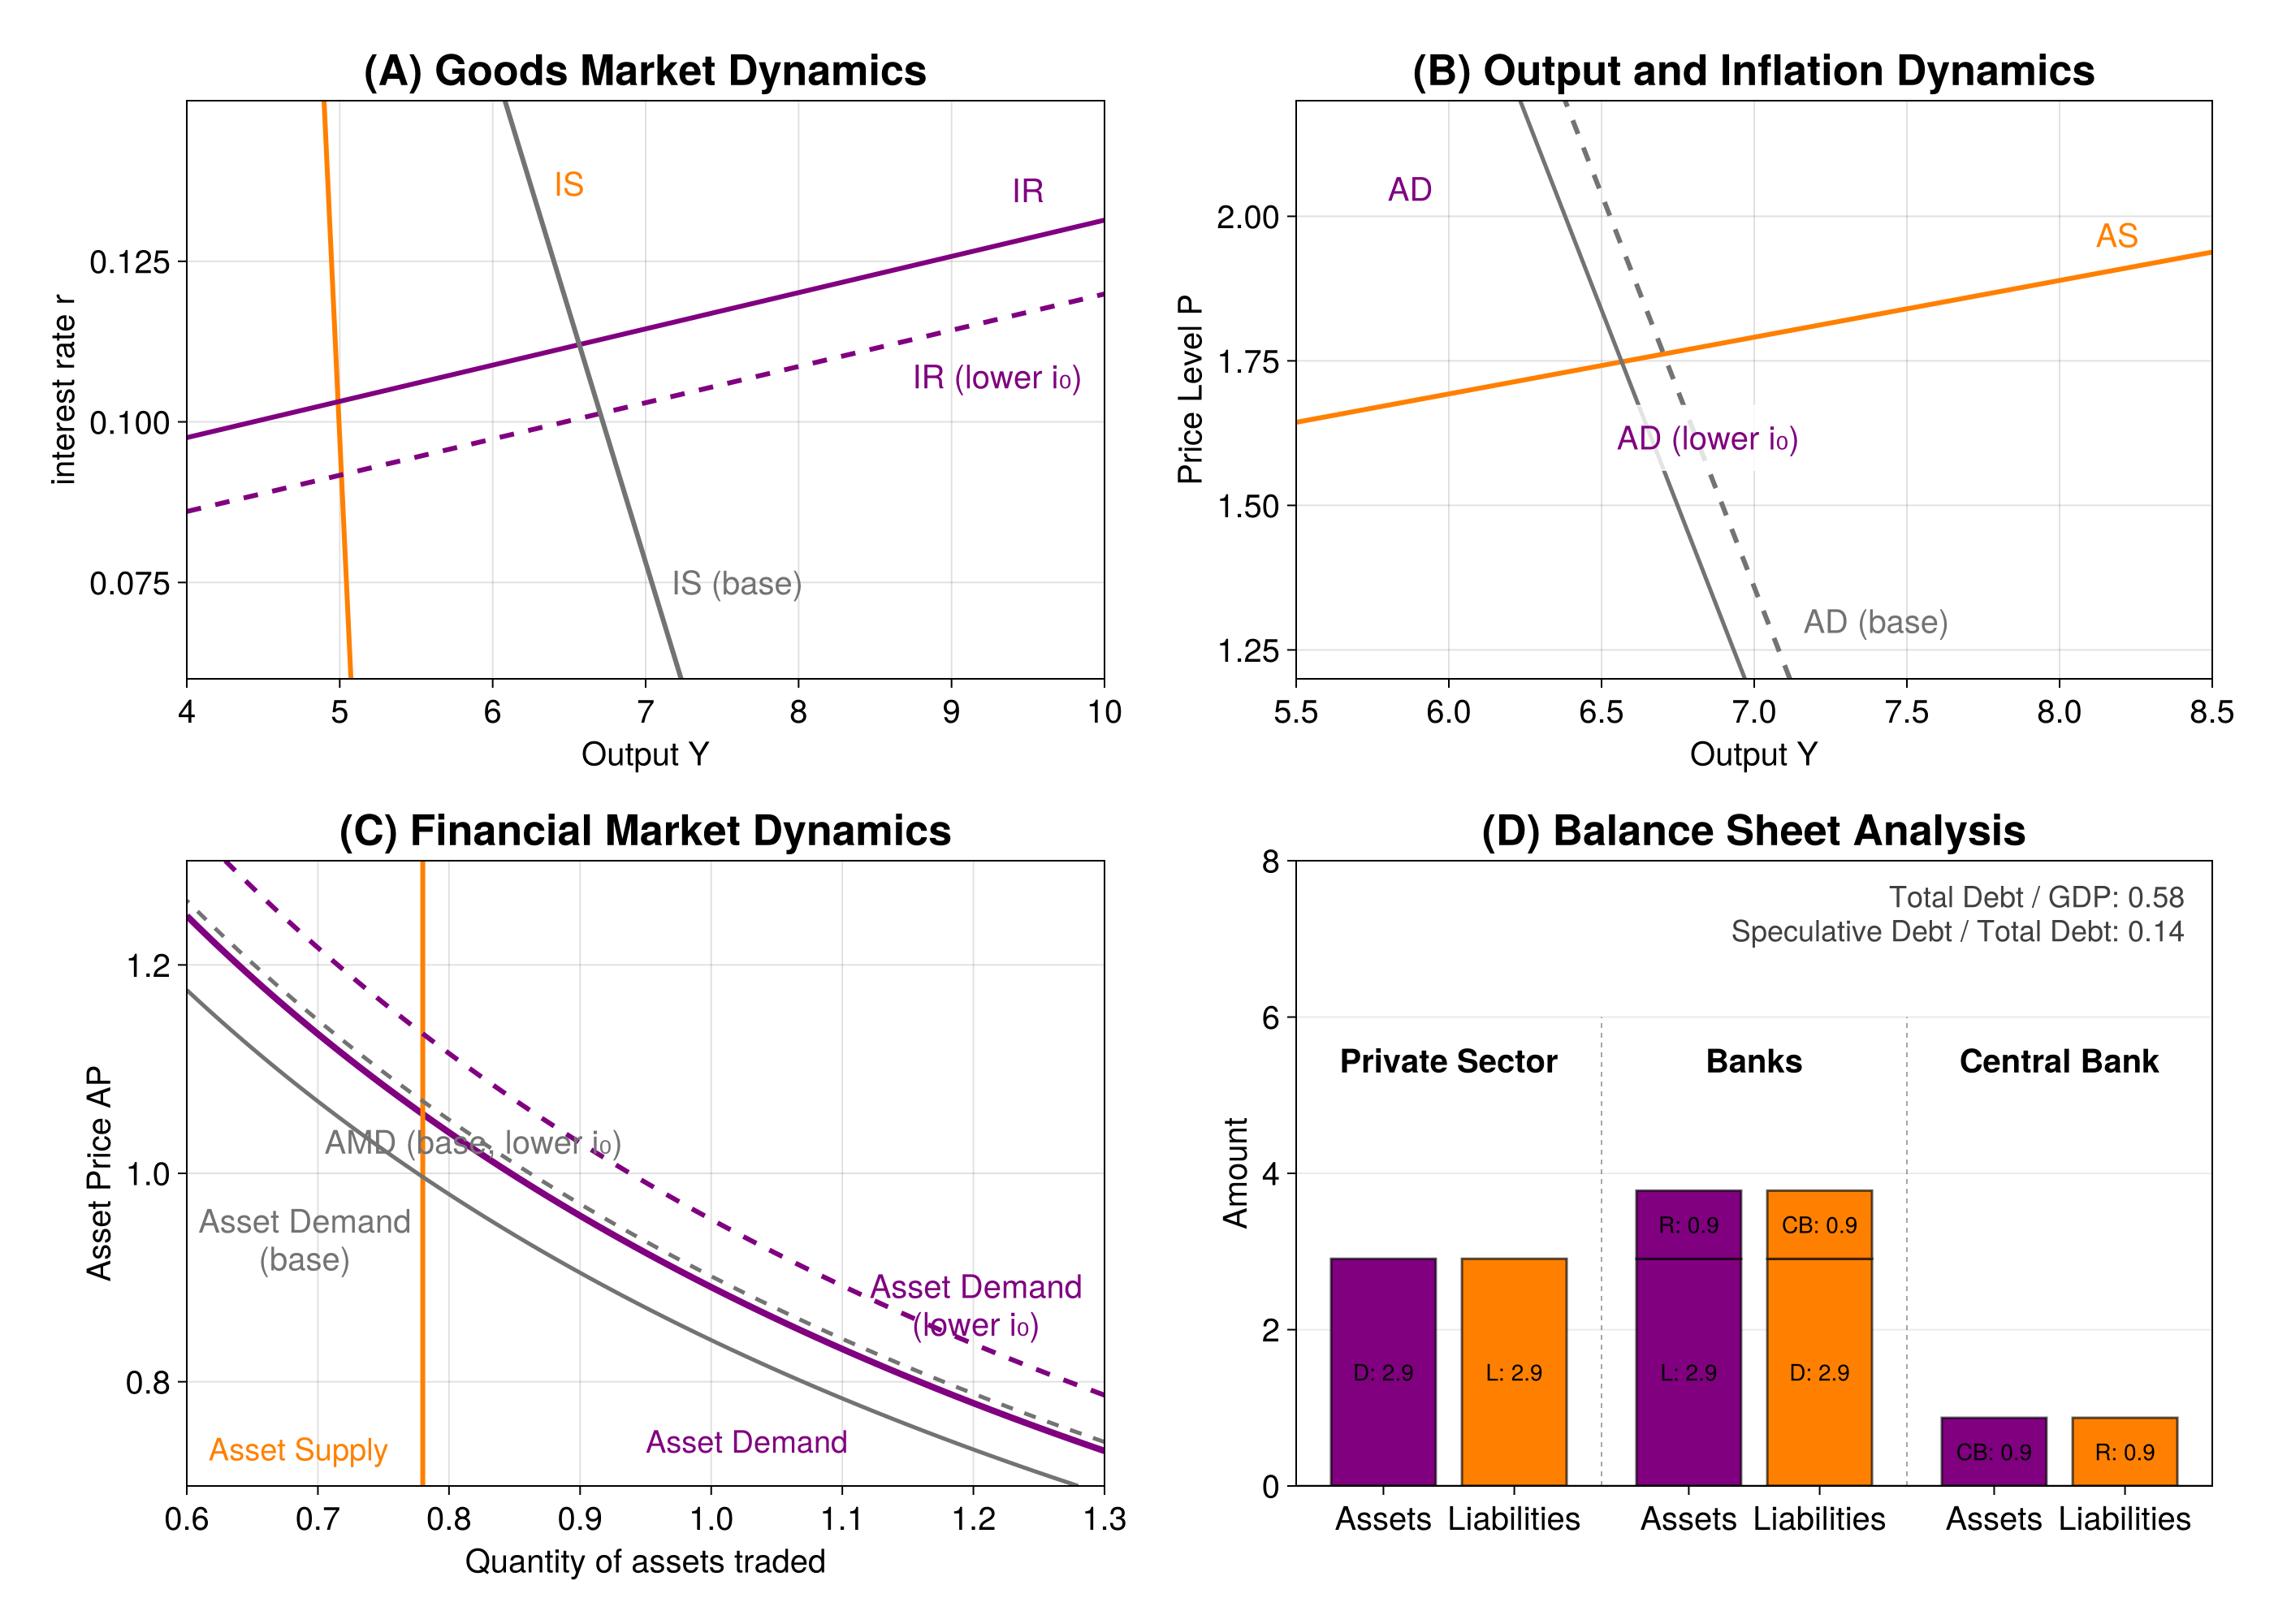

In [18]:
# ── 3. Layout & display ────────────────────────────────────────────────
colgap!(fig.layout, 42)
rowgap!(fig.layout, 22)
rowsize!(fig.layout, 1, Relative(0.48))
rowsize!(fig.layout, 2, Relative(0.52))
fig  # display inline


In [ ]:
# ── 4. Export ───────────────────────────────────────────────────────────
output_dir = normpath(joinpath(@__DIR__, "..", "..", "plots"))
mkpath(output_dir)
pdf_path = joinpath(output_dir, "firmsration_equilibrium_panel.pdf")
png_path = joinpath(output_dir, "firmsration_equilibrium_panel.png")
save(pdf_path, fig; pt_per_unit = 2)
println("Saved: $pdf_path")
save(png_path, fig)
println("Saved: $png_path")


In [ ]:
# ── 5. Verify equilibrium values ────────────────────────────────────────
println("\n── Equilibrium values ──")
for (k, v) in sort!(collect(vars); by = first)
    println(@sprintf("  %12s = %.6f", k, v))
end
